# Import

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt


import seaborn as sns
from matplotlib.ticker import FuncFormatter

from sklearn.covariance import LedoitWolf

from matplotlib.gridspec import GridSpec
from scipy.optimize import minimize
#plt.style.use('seaborn-v0_8-darkgrid')
from dashboard import PortfolioDashboardVisualizer

In [3]:
data = pd.read_csv("data/benchmark_mids_cs.csv")

# Ensure the timestamp is datetime
data["time_stamp"] = pd.to_datetime(data["time_stamp"])

# Sort by ISIN and timestamp to get the correct last entry
data = data.sort_values(["isin", "time_stamp"])

# Keep the last observation per day per ISIN
data = data.groupby(["isin", data["time_stamp"].dt.date], as_index=False).last()
data["time_stamp"] = pd.to_datetime(data["time_stamp"].dt.date)
print(data.shape)
data.head()

(26622, 10)


,isin,Unnamed: 0,time_stamp,price,yield,country_iso,mat_cat,source,remaining_maturity,dv01
0,DE0001102366,2640,2015-01-01,104.3100,0.5400,DE,10,ref,9.618070,0.000957
1,DE0001102366,1980,2015-01-02,104.7105,0.4965,DE,10,ref,9.615332,0.000962
2,DE0001102366,1320,2015-01-05,104.5205,0.5165,DE,10,ref,9.607118,0.000959
3,DE0001102366,660,2015-01-06,105.2050,0.4450,DE,10,ref,9.604381,0.000966
4,DE0001102366,0,2015-01-07,104.8350,0.4835,DE,10,ref,9.601643,0.000961


In [4]:
# Parse timestamp BEFORE sorting/resampling
#data["time_stamp"] = pd.to_datetime(data["time_stamp"], utc=True)

# Consistent typing on mat_cat (string is safer for column labels)
data["mat_cat"] = data["mat_cat"].astype(str)
# Sort within each contract series
data = data.sort_values(["isin", "time_stamp"]).reset_index(drop=True)

# --- Δy by ISIN (no cross-ISIN leakage) ---
# If yield is in percent (e.g., 0.4835%), convert to decimal before differencing

y_level = data["yield"] / 100.0
data["dy"] = y_level.groupby(data["isin"]).diff()  # Δy in decimal (e.g., 1 bp = 0.0001)

# Also keep Δy in bp if needed
data["dy_bp"] = data["dy"] * 1e4  # basis points

# (Futures) We will build a *risk-normalized* return per unit DV01 next.
# For IR futures, linearized PnL ≈ - DV01 * Δy. Per unit DV01, return ≈ -Δy.
# This avoids notional/DV01 scaling headaches at optimization time.
data["pnl_yield_move_unit"] = -data["dy_bp"]*data["dv01"]  
data["pnl_coupon_unit"] = (data.groupby("isin")["yield"].shift(1) * (1/252) / 100)  
data["pnl_total_unit"] = data["pnl_yield_move_unit"] + data["pnl_coupon_unit"] 
data.head()

,isin,Unnamed: 0,time_stamp,price,yield,country_iso,mat_cat,source,remaining_maturity,dv01,dy,dy_bp,pnl_yield_move_unit,pnl_coupon_unit,pnl_total_unit
0,DE0001102366,2640,2015-01-01,104.3100,0.5400,DE,10,ref,9.618070,0.000957,NaN,NaN,NaN,NaN,NaN
1,DE0001102366,1980,2015-01-02,104.7105,0.4965,DE,10,ref,9.615332,0.000962,-0.000435,-4.35,0.004183,0.000021,0.004204
2,DE0001102366,1320,2015-01-05,104.5205,0.5165,DE,10,ref,9.607118,0.000959,0.000200,2.00,-0.001917,0.000020,-0.001898
3,DE0001102366,660,2015-01-06,105.2050,0.4450,DE,10,ref,9.604381,0.000966,-0.000715,-7.15,0.006904,0.000020,0.006924
4,DE0001102366,0,2015-01-07,104.8350,0.4835,DE,10,ref,9.601643,0.000961,0.000385,3.85,-0.003702,0.000018,-0.003684


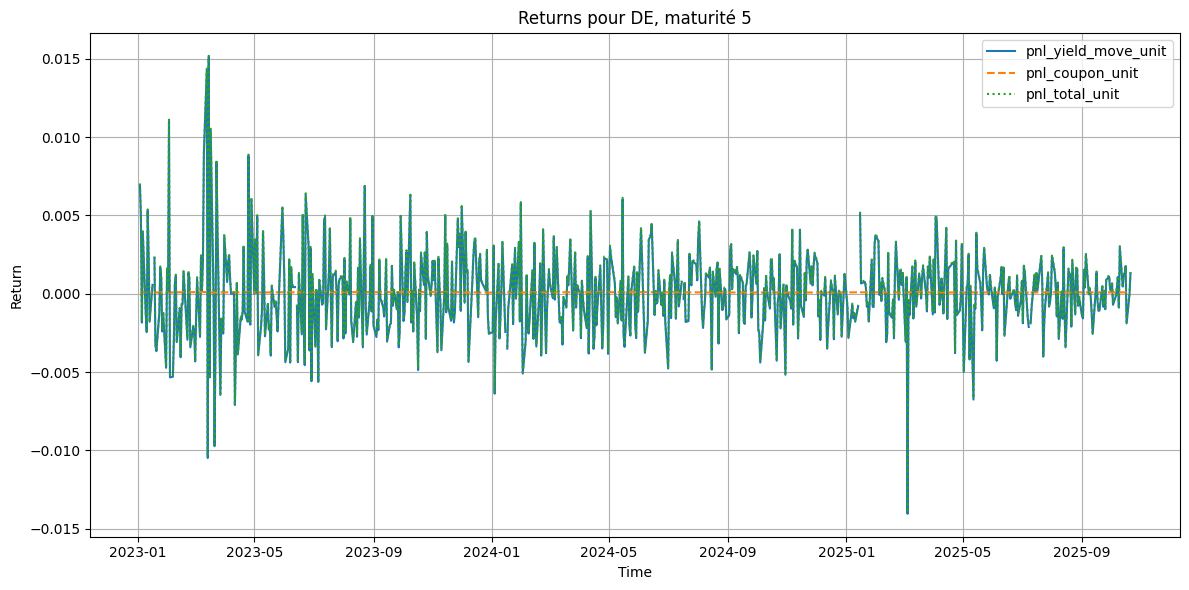

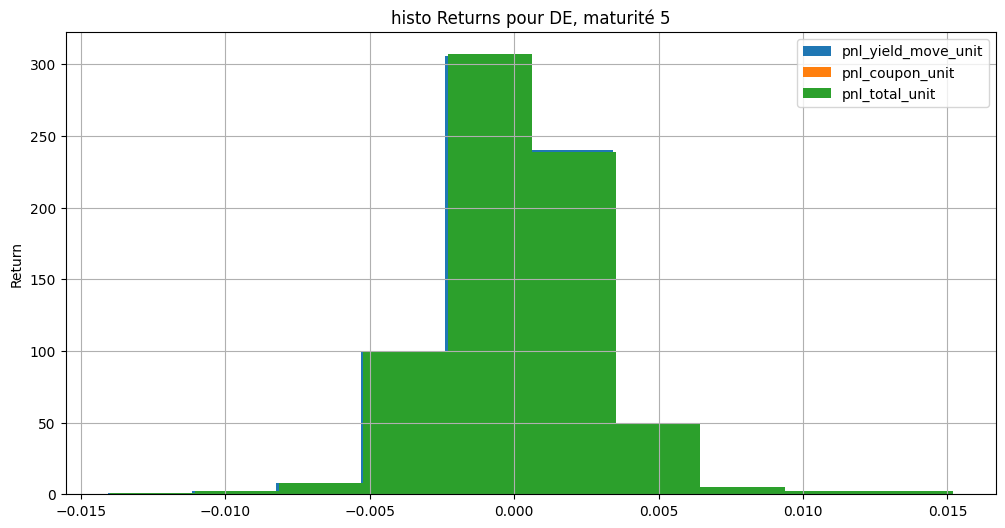

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -----------------------------
# Variables à modifier facilement
# -----------------------------
country = "DE"                # Pays à filtrer
maturity = "5"                # Maturité à filtrer (valeur de mat_cat)
return_col1 = "pnl_yield_move_unit"   # Colonne de return DV01
return_col2 = "pnl_coupon_unit" # Colonne de coupon quotidien
return_col3 = "pnl_total_unit"    # Colonne de return total

start_date = "2023-01-01"    # Date de début du plot
end_date = "2025-12-31"      # Date de fin du plot

# -----------------------------
# Filtrage du DataFrame
# -----------------------------
df_plot = data.loc[
    (data["country_iso"] == country) &
    (data["mat_cat"] == maturity) &
    (data["time_stamp"] >= pd.to_datetime(start_date)) &
    (data["time_stamp"] <= pd.to_datetime(end_date))
]

# -----------------------------
# Plot avec matplotlib
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(df_plot["time_stamp"], df_plot[return_col1], label=return_col1, linestyle="-")
plt.plot(df_plot["time_stamp"], df_plot[return_col2], label=return_col2, linestyle="--")
plt.plot(df_plot["time_stamp"], df_plot[return_col3], label=return_col3, linestyle=":")
plt.title(f"Returns pour {country}, maturité {maturity}")
plt.xlabel("Time")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
plt.hist(df_plot[return_col1], label=return_col1)
plt.hist(df_plot[return_col2], label=return_col2)
plt.hist(df_plot[return_col3], label=return_col3)
plt.title(f"histo Returns pour {country}, maturité {maturity}")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.show()

Bonne tête de return !

# Estimation des return

In [6]:
#On met data sous le bon format. Ce qu'on veut c'est :
# Date | Finacial product (ex FR_5 pour France bond mat 5) | Return
val = "pnl_total_unit"

data_completed = data[["time_stamp", "country_iso", "mat_cat", val]].copy()
data_completed["product"] = data_completed["country_iso"].astype(str) + "_" + data_completed["mat_cat"].astype(str)
data_completed = data_completed.drop(columns=["country_iso", "mat_cat"])
data_completed["time_stamp"] = pd.to_datetime(data_completed["time_stamp"])

data_completed.head()




,time_stamp,pnl_total_unit,product
0,2015-01-01,NaN,DE_10
1,2015-01-02,0.004204,DE_10
2,2015-01-05,-0.001898,DE_10
3,2015-01-06,0.006924,DE_10
4,2015-01-07,-0.003684,DE_10


# Ajout spread et curve 

In [7]:
def add_spread_curve(data):
    """
    Ajoute au format long (time_stamp, product, pnl_total_unit) :
      - Obligations "simples" : FR_2, DE_10, ...
      - Spreads entre pays à même maturité      : FR_DE_2        (type = spread_country)
      - Spreads intra-pays entre maturités      : FR_2_5         (type = spread_curve)
      - Butterflies intra-pays                  : FR_fly_2_5_10  (type = butterfly_curve)
      - Différences de pente entre pays         : FR_DE_slope_2_10 (type = slope_diff_country)

    Paramètres
    ----------
    data : DataFrame
        Colonnes attendues : time_stamp, product, pnl_total_unit

    Retour
    ------
    DataFrame long enrichi avec une colonne 'type'.
    """

    df = data.copy()

    # Marquer les produits originaux
    product_type = {p: "bond" for p in df["product"].unique()}

    # Extraction des pays et maturités à partir de product = "FR_5", "DE_10", etc.
    products = df["product"].unique()
    countries = sorted({p.split("_")[0] for p in products})

    # tri des maturités de manière numérique si possible (2, 5, 10, 30...)
    def sort_mats(mats):
        try:
            return sorted(mats, key=lambda x: float(x))
        except ValueError:
            return sorted(mats)

    maturities = sort_mats({p.split("_")[1] for p in products})

    # Pivot large : colonnes = produits
    wide = df.pivot(index="time_stamp", columns="product", values="pnl_total_unit").sort_index()

    # ----------------------------
    # 1) SPREADS ENTRE PAYS (même maturité)
    # ----------------------------
    for mat in maturities:
        prods_mat = [f"{c}_{mat}" for c in countries if f"{c}_{mat}" in wide.columns]

        for i in range(len(prods_mat)):
            for j in range(i + 1, len(prods_mat)):
                p1, p2 = prods_mat[i], prods_mat[j]
                c1, c2 = p1.split("_")[0], p2.split("_")[0]

                spread_name = f"{c1}_{c2}_{mat}"
                if spread_name not in wide.columns:
                    wide[spread_name] = wide[p1] - wide[p2]
                    product_type[spread_name] = "spread_country"

    # ----------------------------
    # 2) SPREADS INTRA-PAYS (courbe)
    # ----------------------------
    for c in countries:
        mats_c = sort_mats([p.split("_")[1] for p in products if p.startswith(c + "_")])

        for i in range(len(mats_c)):
            for j in range(i + 1, len(mats_c)):
                m1, m2 = mats_c[i], mats_c[j]
                p1, p2 = f"{c}_{m1}", f"{c}_{m2}"

                if p1 in wide.columns and p2 in wide.columns:
                    spread_name = f"{c}_{m1}_{m2}"
                    if spread_name not in wide.columns:
                        wide[spread_name] = wide[p1] - wide[p2]
                        product_type[spread_name] = "spread_curve"

    # ----------------------------
    # 3) BUTTERFLIES INTRA-PAYS (level/slope/curvature)
    #    fly(c, m1, m2, m3) = c_m1 - 2*c_m2 + c_m3
    # ----------------------------
    for c in countries:
        mats_c = sort_mats([p.split("_")[1] for p in products if p.startswith(c + "_")])

        # m1 < m2 < m3 consécutives dans la liste triée
        for i in range(len(mats_c) - 2):
            m1, m2, m3 = mats_c[i], mats_c[i + 1], mats_c[i + 2]
            p1, p2, p3 = f"{c}_{m1}", f"{c}_{m2}", f"{c}_{m3}"

            if all(p in wide.columns for p in (p1, p2, p3)):
                fly_name = f"{c}_fly_{m1}_{m2}_{m3}"
                if fly_name not in wide.columns:
                    wide[fly_name] = wide[p1] - 2 * wide[p2] + wide[p3]
                    product_type[fly_name] = "butterfly_curve"

    # ----------------------------
    # 4) DIFFÉRENCES DE PENTE ENTRE PAYS
    #    slope_diff(c1,c2; m_low,m_high) = (c1_mhigh - c1_mlow) - (c2_mhigh - c2_mlow)
    # ----------------------------
    for idx_low in range(len(maturities) - 1):
        for idx_high in range(idx_low + 1, len(maturities)):
            m_low, m_high = maturities[idx_low], maturities[idx_high]

            for i in range(len(countries)):
                for j in range(i + 1, len(countries)):
                    c1, c2 = countries[i], countries[j]
                    p1_low, p1_high = f"{c1}_{m_low}", f"{c1}_{m_high}"
                    p2_low, p2_high = f"{c2}_{m_low}", f"{c2}_{m_high}"

                    if all(p in wide.columns for p in (p1_low, p1_high, p2_low, p2_high)):
                        slope_name = f"{c1}_{c2}_slope_{m_low}_{m_high}"
                        if slope_name not in wide.columns:
                            slope_c1 = wide[p1_high] - wide[p1_low]
                            slope_c2 = wide[p2_high] - wide[p2_low]
                            wide[slope_name] = slope_c1 - slope_c2
                            product_type[slope_name] = "slope_diff_country"

    # ----------------------------
    # Retour au format long
    # ----------------------------
    long = wide.reset_index().melt(
        id_vars="time_stamp",
        var_name="product",
        value_name="pnl_total_unit"
    )

    # Ajouter la colonne type
    long["type"] = long["product"].map(product_type).fillna("unknown")

    return long

long = add_spread_curve(data_completed)
long.head(10)


,time_stamp,product,pnl_total_unit,type
0,2015-01-01,DE_10,NaN,bond
1,2015-01-02,DE_10,0.004204,bond
2,2015-01-05,DE_10,-0.001898,bond
3,2015-01-06,DE_10,0.006924,bond
4,2015-01-07,DE_10,-0.003684,bond
5,2015-01-08,DE_10,-0.002378,bond
6,2015-01-09,DE_10,0.002037,bond
7,2015-01-12,DE_10,0.000980,bond
8,2015-01-13,DE_10,0.000115,bond
9,2015-01-14,DE_10,0.005185,bond


# Class Portfolio à date t 

In [30]:
from sklearn.covariance import LedoitWolf
class Portfolio:
    def __init__(self, data, date, benchmark="ew", long_only=True, lamb=1.0, window_days=None, sigma_level = 0.01, span = 60):
        """
        data: Pandas dataframe withe time_stamp, product, pnl_total_unit
        date: datetime-like
            Rebalance (estimation) date. Uses history up to and including this date.
        long_only: if True, project to simplex after solving (approximate).
        lamb: risk-aversion for mean-variance utility: maximize mu'w - lambda * w'Σw.
        window_days: if set, only use last N calendar days of history for μ, Σ.
        """
        self.data = data
        self.date = pd.to_datetime(date)
        self.benchmark = benchmark
        self.returns = None
        self.mean_returns = None
        self.cov_matrix = None
        self.weights = None

        self.long_only = long_only
        self.lamb = float(lamb)
        self.window_days = window_days
        self.benchmark_weights = None
        self.sigma_level = sigma_level
        self.span = span

    def get_returns_until(self):
        """filter up to self.date."""
        R = self.data[self.data["time_stamp"] < self.date]

        if self.window_days is not None:
            start_cut  = self.date - pd.Timedelta(days=int(self.window_days))
            R = R[R["time_stamp"] >= start_cut]
        #print(R)
        # Do not drop to full intersection early; compute pairwise μ, Σ
        self.returns = R

    def estimate_returns(self):
        """EWMA (exponential weighted mean) of returns per product."""
        span=self.span #Span control the half life

        # on prend seulement date, produit et return
        df = self.returns[["time_stamp", "product", "pnl_total_unit"]].copy()
        df = df.sort_values(["product", "time_stamp"])
        

        # EWMA par produit
        ewma = (
            df.groupby("product")["pnl_total_unit"]
            .apply(lambda x: x.ewm(span=span, adjust=False).mean().iloc[-1])
            .reset_index(name="ewma_unit_pnl")
        )
        

        self.mean_returns = ewma

    def estimate_exp_cov_matrix(self):
        """
        EWMA covariance (RiskMetrics) + shrinkage toward diagonal.
        """

        l = (self.span - 1) / (self.span + 1)
        shrink = 0.001

        panel = self.returns.pivot(
            index="time_stamp",
            columns="product",
            values="pnl_total_unit"
        ).sort_index()

        X = panel.fillna(0).values
        n, k = X.shape

        # EWMA weights
        weights = (1 - l) * l ** np.arange(n)[::-1]   # newest has highest weight
        W = np.sqrt(weights)[:, None]                 # reshape (n,1)

        # Weighted data
        Xw = X * W

        # Covariance = Xw.T @ Xw
        Sigma = Xw.T @ Xw

        # Shrinkage
        diag = np.diag(np.diag(Sigma))
        Sigma = (1 - shrink) * Sigma + shrink * diag

        self.cov_matrix = pd.DataFrame(Sigma, columns=panel.columns, index=panel.columns)

 
    def estimate_cov_matrix_Ledoit(self):
        """
        Estimate covariance matrix using Ledoit-Wolf shrinkage.
        """
        panel = self.returns.pivot(
            index="time_stamp",
            columns="product",
            values="pnl_total_unit"
        ).sort_index()

        X = panel.fillna(0).values
        lw = LedoitWolf().fit(X)     
        cov_matrix = lw.covariance_

        self.cov_matrix = pd.DataFrame(
            cov_matrix,
            columns=panel.columns,
            index=panel.columns
        )

    def markowitz2(self, lambda_risk=None, w_prev=None):
        """
        Optimisation Markowitz classique avec long-only et risque intégré dans l'objectif.

        max w.T @ mean_returns - lambda_risk * w.T @ cov_matrix @ w
        s.t. sum(w) = 1, wi >= 0 si long_only

        Arguments :
            lambda_risk : float, trade-off risque/rendement (si None, prend self.lamb)
            w_prev      : array, poids du portefeuille précédent pour warm-start

        Retourne :
            self.weights : DataFrame des poids optimaux
        """
        # Au moment de l’optim :
        mean = self.mean_returns.set_index("product")["ewma_unit_pnl"]
        mean = mean.reindex(self.cov_matrix.index)  # alignement
        mean_returns = mean.values
        cov_matrix = self.cov_matrix.values

        n = len(mean_returns)
        long_only = self.long_only
        lambda_risk = self.lamb
    
        

        # Fonction objectif (à minimiser)
        def objective(w):
            # On minimise -[E[R] - λ Var(R)] = λ w.T Σ w - w.T μ
            return lambda_risk * w @ cov_matrix @ w - w @ mean_returns

        # Gradient analytique
        def grad_objective(w):
            return 2 * lambda_risk * cov_matrix @ w - mean_returns

        # Contraintes : somme des poids = 1
        constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1,
                        'jac': lambda w: np.ones_like(w)}]
        
        # Bornes
        bounds = [(0, 1) if long_only else (-0.5, 2)] * n

        # Initial guess
        if w_prev is not None:
            w0 = np.clip(w_prev.values.flatten(), 0, 1) if long_only else w_prev.values.flatten()
            w0 = w0 / np.sum(w0)  # normalisation pour somme = 1
        else:
            w0 = np.ones(n) / n

        # Minimisation
        res = minimize(objective, w0, jac=grad_objective,
                    bounds=bounds, constraints=constraints,
                    method='SLSQP', options={'ftol':1e-9, 'disp':False, 'maxiter':1000})

        if not res.success:
            raise ValueError("Optimisation échouée : " + res.message)

        # Résultat
        weights_opt = res.x
        self.weights = pd.DataFrame(weights_opt, index=self.cov_matrix.index, columns=[self.date])

        return self.weights


    def benchmark_w(self):
        n = len(self.mean_returns)
        if self.benchmark == "ew":
            self.benchmark_weights = pd.DataFrame(np.ones(n) / n,index=self.mean_returns["product"], columns=[self.date])
        else:
            raise NotImplementedError("Only 'ew' benchmark implemented for now.")

    def process(self):
        self.get_returns_until()
        self.estimate_returns()
        #self.estimate_cov_matrix_Ledoit()
        self.estimate_exp_cov_matrix()
        self.markowitz2() #paramètre très sensible
        self.benchmark_w()
        return self.weights


In [31]:
date = "2023-06-01"


pf = Portfolio(long, date, benchmark="ew", long_only=True, window_days=200,lamb=100)
#print(pf.returns)
w = pf.process() 
#print(pf.mean_returns)
print(w)

                   2023-06-01
product                      
DE_10            2.848645e-18
DE_10_15         3.781825e-18
DE_10_30         5.790562e-17
DE_15            0.000000e+00
DE_15_30         2.110778e-17
...                       ...
IT_5_15          0.000000e+00
IT_5_30          8.697127e-19
IT_fly_10_15_30  0.000000e+00
IT_fly_2_5_10    1.740772e-18
IT_fly_5_10_15   0.000000e+00

[99 rows x 1 columns]


# Creation du time series portfolio

In [32]:
class TimeSeriesPortfolio:
    def __init__(self, data, start_date, end_date, rebalance_freq='1M',
                 long_only=False, lamb=1.0, benchmark="ew", 
                 window_days=None, sigma_level=0.01, capital_init=100_000, span = 60):

        # Convert time_stamp to Timestamp
        self.data = data.copy()
        self.data["time_stamp"] = pd.to_datetime(self.data["time_stamp"])
        self.start_date = pd.to_datetime(start_date)
        self.end_date = pd.to_datetime(end_date)
        self.rebalance_freq = rebalance_freq
        self.long_only = long_only
        self.lamb = float(lamb)
        self.benchmark = benchmark
        self.window_days = window_days
        self.sigma_level = sigma_level
        self.capital_init = capital_init
        self.span = span
        
        # Univers global d'actifs (tous les products jamais vus dans self.data)
        self.asset_universe = sorted(self.data["product"].unique())
        
        self.countries = sorted({p.split("_")[0] for p in self.asset_universe})

        self.rebalance_dates = None
        self.all_dates = None
        self.weights_history = pd.DataFrame()
        self.exposures_history = pd.DataFrame()
        self.portfolio_returns = pd.Series(dtype=float)
        self.benchmark_returns = pd.Series(dtype=float)
        self.metrics = {}


        # Filter data for rolling window
        start_window = self.start_date - pd.Timedelta(days=5_000)
        self.R = self.data[
            (self.data["time_stamp"] >= start_window) &
            (self.data["time_stamp"] <= self.end_date)
        ]

    def freq_to_pd_freq(self):
        f = self.rebalance_freq.upper()
        if f.endswith(('D', 'B', 'W', 'M')):
            return f
        return '1M'

    def generate_rebalance_dates(self):
        all_dates = pd.DatetimeIndex(self.R["time_stamp"].unique())
        mask = (all_dates >= self.start_date) & (all_dates <= self.end_date)
        all_dates = all_dates[mask].sort_values()
        self.all_dates = all_dates

        if len(all_dates) == 0:
            raise ValueError("No market dates in the selected window.")

        targets = pd.date_range(start=self.start_date, end=self.end_date,
                                freq=self.freq_to_pd_freq())
        reb = []
        for tgt in targets:
            tgt = pd.Timestamp(tgt)  # assure tz-naive Timestamp
            pos = all_dates.searchsorted(tgt)
            if pos < len(all_dates):
                d = all_dates[pos]
                if (len(reb) == 0) or (d != reb[-1]):
                    reb.append(d)

        if all_dates[-1] not in reb:
            reb.append(all_dates[-1])

        self.rebalance_dates = pd.DatetimeIndex(reb)

    def generate_portfolios(self):
        if self.rebalance_dates is None or self.all_dates is None:
            self.generate_rebalance_dates()

        weights_list = []
        exposures_list = []

        pf_rel_returns = []
        bm_rel_returns= []
        returns_dates = []

        pf_pnl_daily = []
        bm_pnl_daily = []

        capital = self.capital_init
        current_value = capital
        current_value_bm = capital

        for i, t in enumerate(self.rebalance_dates[:-1]):
            t_next = self.rebalance_dates[i + 1]
            pf = Portfolio(
                data=self.data,
                date=t,
                benchmark=self.benchmark,
                long_only=self.long_only,
                lamb=self.lamb,
                window_days=self.window_days,
                sigma_level=self.sigma_level,
                span = self.span
            )
            
            w_df = pf.process()
            w = w_df.iloc[:, 0]  # Series: index = produits présents dans Σ à cette date

            # 1) Reindexer les poids sur l'univers global, en mettant 0 où l'actif n'est pas dans Σ
            w_full = w.reindex(self.asset_universe).fillna(0.0)

            # Benchmark
            w_bm = pf.benchmark_weights.reindex(self.asset_universe).iloc[:, 0].fillna(0.0)

            # 2) Normalisation des expositions
            target_notional = self.capital_init
            denom_pf = np.sum(np.abs(w_full.values))
            if denom_pf > 0:
                exposure_full = w_full * (target_notional / denom_pf)
            else:
                exposure_full = w_full.copy()

            denom_bm = np.sum(np.abs(w_bm.values))
            if denom_bm > 0:
                exposure_bm_full = w_bm * (target_notional / denom_bm)
            else:
                exposure_bm_full = w_bm.copy()

            # 3) Slice des PnL unitaires pour la période (t, t_next]
            period_mask = (self.R["time_stamp"] > t) & (self.R["time_stamp"] <= t_next)
            R_slice_long = self.R.loc[period_mask].copy()

            R_slice = R_slice_long.pivot(
                index="time_stamp",
                columns="product",
                values="pnl_total_unit"
            )

            # On garde uniquement les colonnes de l’univers global (intersection)
            common_cols = [p for p in self.asset_universe if p in R_slice.columns]
            R_slice = R_slice[common_cols].fillna(0.0)

            # 4) Aligner les expositions sur ces colonnes
            exp_pf = exposure_full.reindex(common_cols).values
            exp_bm = exposure_bm_full.reindex(common_cols).values

            # 5) PnL par jour
            pf_pnl_day = R_slice.values @ exp_pf
            bm_pnl_day = R_slice.values @ exp_bm

            pf_pnl_daily.extend(pf_pnl_day)
            bm_pnl_daily.extend(bm_pnl_day)

            pf_rel_returns.extend((pf_pnl_day / current_value).tolist())
            bm_rel_returns.extend((bm_pnl_day / current_value_bm).tolist())
            returns_dates.extend(R_slice.index.tolist())

            current_value += pf_pnl_day.sum()
            current_value_bm += bm_pnl_day.sum()

            # 6) Stocker les poids / expositions sur l’univers global
            weights_list.append(w_full.values)
            exposures_list.append(exposure_full.values)

        asset_names = self.asset_universe
        self.weights_history = pd.DataFrame(
            weights_list,
            index=self.rebalance_dates[:-1],
            columns=asset_names
        )
        self.exposures_history = pd.DataFrame(
            exposures_list,
            index=self.rebalance_dates[:-1],
            columns=asset_names
        )


        if len(returns_dates) > 0:
            self.portfolio_returns = pd.Series(pf_rel_returns, index=pd.DatetimeIndex(returns_dates))
            self.benchmark_returns = pd.Series(bm_rel_returns, index=pd.DatetimeIndex(returns_dates))

        # Cumulative return
        pf_cum_return = (1 + self.portfolio_returns.fillna(0)).cumprod()
        bm_cum_return = (1 + self.benchmark_returns.fillna(0)).cumprod()

        # Cumulative PnL
        pf_value = pd.Series(capital + np.array(pf_pnl_daily).cumsum(), index=pd.DatetimeIndex(returns_dates))
        bm_value = pd.Series(capital + np.array(bm_pnl_daily).cumsum(), index=pd.DatetimeIndex(returns_dates))
        pf_pnl = pd.Series(pf_pnl_daily, index=pd.DatetimeIndex(returns_dates))
        bm_pnl = pd.Series(bm_pnl_daily, index=pd.DatetimeIndex(returns_dates))

        trading_days = 252
        pf_mean = self.portfolio_returns.mean()
        pf_std = self.portfolio_returns.std()
        pf_sharpe = (pf_mean / pf_std * np.sqrt(trading_days)) if pf_std != 0 else np.nan

        # Metrics
        roll_max = pf_value.cummax() if len(pf_value) > 0 else pd.Series(dtype=float)
        dd = (pf_value - roll_max) / roll_max if len(pf_value) > 0 else pd.Series(dtype=float)

        self.metrics = {
            "initial_capital": capital,
            "portfolio_value": pf_value,
            "benchmark_value": bm_value,
            "portfolio_pnl": pf_pnl,
            "benchmark_pnl": bm_pnl,
            "pf_cumulative_return": pf_cum_return,
            "bm_cumulative_return": bm_cum_return,
            "mean_return": pf_mean,
            "volatility": pf_std,
            "sharpe": pf_sharpe,
            "gross_exposure": np.abs(self.exposures_history).sum(axis=1),
            "net_exposure": self.exposures_history.sum(axis=1),
            "drawdown": dd,
            "max_drawdown": dd.min() if len(dd) > 0 else np.nan
        }

        print("Tout a marché !!")
    
    def _decompose_product_legs(self, product):
        """
        Décompose un product en jambes élémentaires (country, maturity, coef).

        Conventions de nommage gérées :
          - Bond simple           : FR_5
          - Spread pays           : FR_DE_5              -> +FR_5, -DE_5
          - Spread courbe         : FR_2_5 ou FR_10_5    -> +FR_2/10, -FR_5
          - Butterfly intra-pays  : FR_fly_2_5_10        -> +FR_2, -2 FR_5, +FR_10
          - Slope diff pays       : FR_DE_slope_2_10     -> (FR_10 - FR_2) - (DE_10 - DE_2)

        Retourne une liste de tuples (country, maturity, coef).
        """
        parts = product.split("_")

        # Bond simple : "FR_5"
        if len(parts) == 2:
            c, m = parts
            return [(c, m, 1.0)]

        # Cas len(parts) == 3 : soit spread pays FR_DE_5, soit spread courbe FR_2_5 / FR_10_5
        if len(parts) == 3:
            p0, p1, p2 = parts

            # On utilise la vraie liste de pays pour décider
            # 1) Spread pays : FR_DE_5
            if p0 in getattr(self, "countries", []) and p1 in getattr(self, "countries", []):
                c1, c2, mat = p0, p1, p2
                return [(c1, mat,  1.0),
                        (c2, mat, -1.0)]

            # 2) Spread courbe : FR_2_5, FR_10_5, etc.
            if p0 in getattr(self, "countries", []):
                c, m1, m2 = p0, p1, p2
                return [(c, m1,  1.0),
                        (c, m2, -1.0)]

        # Butterfly : FR_fly_2_5_10
        if len(parts) == 5 and parts[1] == "fly":
            c, _, m1, m2, m3 = parts
            return [(c, m1,  1.0),
                    (c, m2, -2.0),
                    (c, m3,  1.0)]

        # Slope diff pays : FR_DE_slope_2_10
        if len(parts) == 5 and parts[2] == "slope":
            c1, c2, _, m_low, m_high = parts
            return [
                (c1, m_high,  1.0),
                (c1, m_low,  -1.0),
                (c2, m_high, -1.0),
                (c2, m_low,   1.0),
            ]

        # Cas non reconnu : on ignore
        return []

    
    def exposition_by_country(self):
        """
        Calcule l'exposition par pays en tenant compte des combinaisons linéaires
        des produits (bonds, spreads, butterflies, slopes).

        Pour chaque produit j et chaque jour t :
        expo_country[c, t] = somme_j ( expo_j(t) * coef_{j,c,*} )
        où coef_{j,c,*} vient de la décomposition en jambes (country, maturity, coef).
        """
        df = self.exposures_history.copy()  # index = dates, columns = products

        # Pré-calcul des jambes pour chaque produit
        legs_by_product = {}
        countries = set()

        for p in df.columns:
            legs = self._decompose_product_legs(p)
            legs_by_product[p] = legs
            for c, m, coef in legs:
                countries.add(c)

        if not countries:
            # Aucun produit reconnu -> on renvoie un DF vide mais bien formé
            return pd.DataFrame(index=df.index)

        # DataFrame resultat : dates x pays
        countries = sorted(countries)
        expo_by_country = pd.DataFrame(0.0, index=df.index, columns=countries)

        # Agrégation : pour chaque produit, répartir son expo sur les pays
        for p in df.columns:
            legs = legs_by_product.get(p, [])
            if not legs:
                continue
            exp_p = df[p]  # Series index=date

            for c, m, coef in legs:
                expo_by_country[c] += coef * exp_p

        return expo_by_country
    
    def exposition_by_mat(self):
        """
        Calcule l'exposition par maturité (toutes devises confondues) en tenant
        compte des combinaisons linéaires des produits.

        Pour chaque produit j et chaque jour t :
        expo_mat[m, t] = somme_j ( expo_j(t) * coef_{j,*,m} )
        """
        df = self.exposures_history.copy()  # index = dates, columns = products

        legs_by_product = {}
        maturities = set()

        for p in df.columns:
            legs = self._decompose_product_legs(p)
            legs_by_product[p] = legs
            for c, m, coef in legs:
                maturities.add(m)

        if not maturities:
            return pd.DataFrame(index=df.index)

        maturities = sorted(maturities, key=lambda x: float(x) if str(x).replace(".", "", 1).isdigit() else x)
        expo_by_mat = pd.DataFrame(0.0, index=df.index, columns=maturities)

        for p in df.columns:
            legs = legs_by_product.get(p, [])
            if not legs:
                continue
            exp_p = df[p]

            for c, m, coef in legs:
                expo_by_mat[m] += coef * exp_p

        return expo_by_mat





C:\Users\hugoj\AppData\Local\Temp\ipykernel_5308\1574466351.py:56: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  targets = pd.date_range(start=self.start_date, end=self.end_date,


Tout a marché !!


c:\Users\hugoj\Documents\QF_project\Project_QuantFox\dashboard.py:96: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  pf_m = pf_value.resample(freq).last().fillna(method='ffill') - capital
c:\Users\hugoj\Documents\QF_project\Project_QuantFox\dashboard.py:97: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  bm_m = bm_value.resample(freq).last().fillna(method='ffill') - capital
c:\Users\hugoj\Documents\QF_project\Project_QuantFox\dashboard.py:232: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pf_m = pf_value.resample('M').last()
c:\Users\hugoj\Documents\QF_project\Project_QuantFox\dashboard.py:233: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  bm_m = bm_value.resample('M').last() if bm_value is not None else N

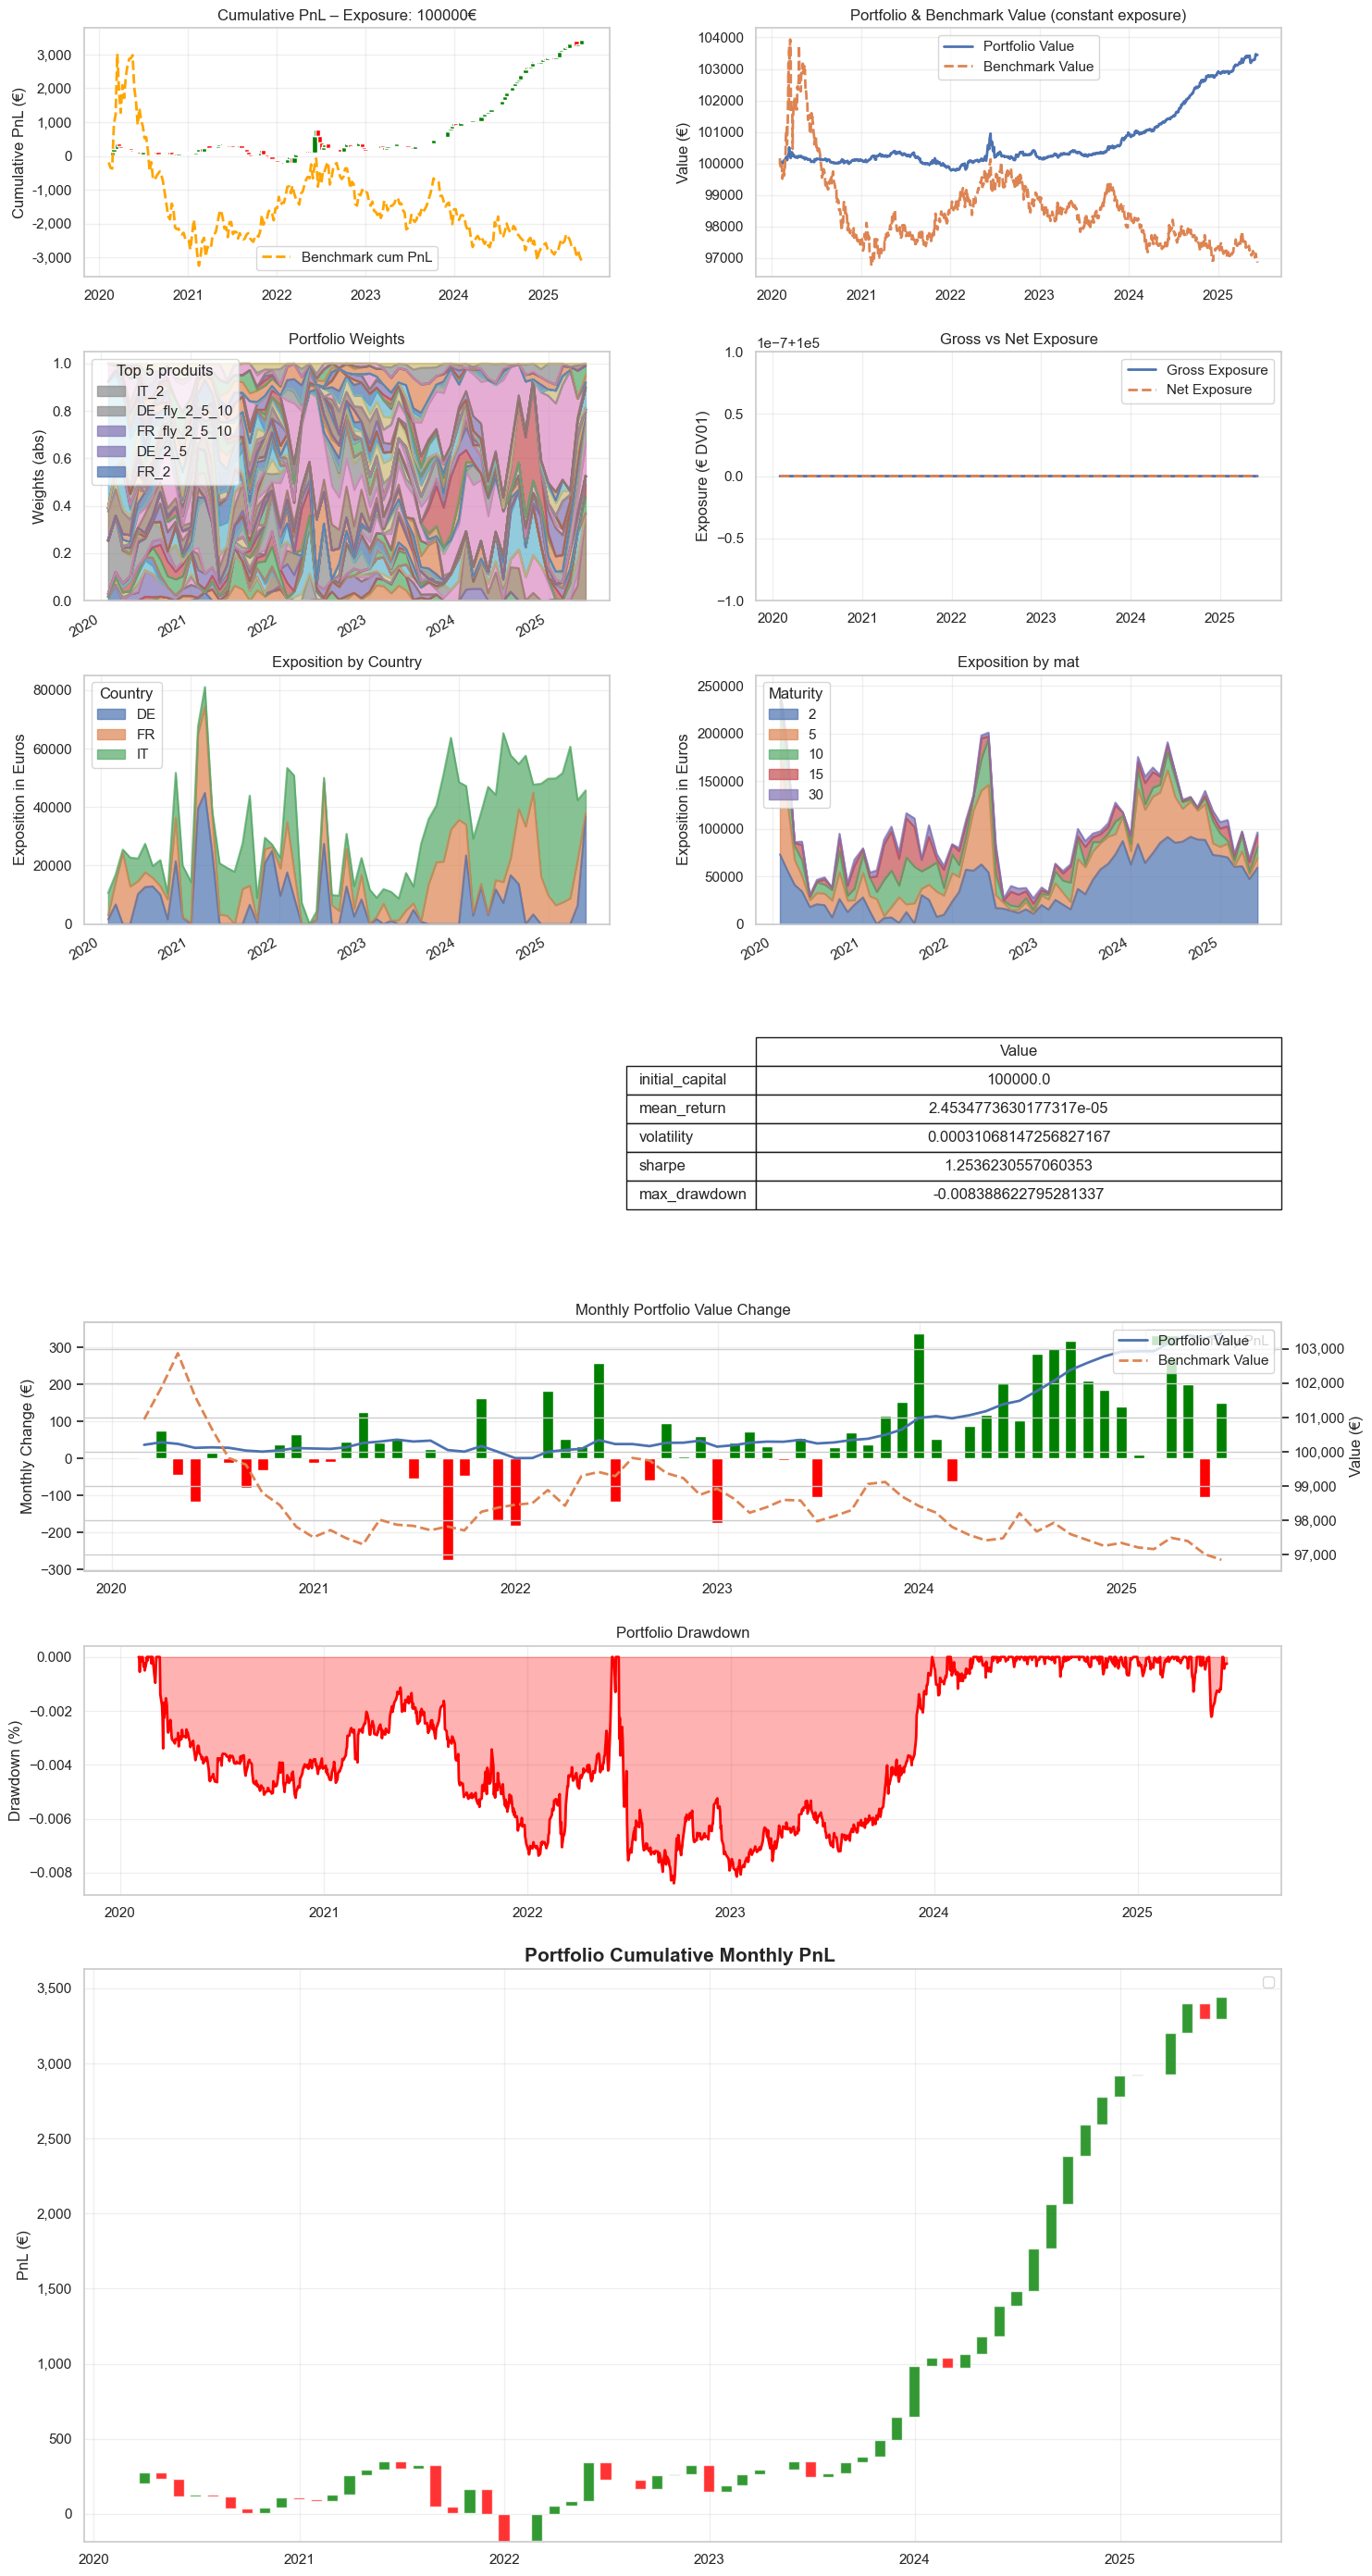

In [34]:
start_date = "2020-01-01"
end_date   = "2025-06-10"


tspf = TimeSeriesPortfolio(
    #data_completed,
    long,
    start_date,
    end_date,
    rebalance_freq="1M",
    long_only=True,
    lamb=1000,
    benchmark="ew",
    window_days=1000,  # à enlever
    span = 60 # demi vie de nos données contrôle la réactivité de notre modèle
    )

tspf.generate_portfolios()

viz = PortfolioDashboardVisualizer(tspf)
viz.plot_dashboard()